# Описание задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average 20. Permeability (air average mD) – проницаемость

**Что нужно сделать**:

Принять участие в соревновании на Kaggle:
Оно доступно по [ссылке](https://www.kaggle.com/competitions/classification-of-oil-and-gas/submissions#).

Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.


# Считывание данных

In [1]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
# Для автомтическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# Файл скачивается в настройках в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'

od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [2]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [5]:
# Посмотрим как выглядят данные, транспониируем таблицу для удобства просмотра
train.head(6).T

,0,1,2,3,4,5
Field name,ZHIRNOV,LAGOA PARDA,ABQAIQ,MURCHISON,WEST PEMBINA,UCHKYR
Reservoir unit,MELEKESKIAN,LAGOA PARDA (URUCUTUCA),ARAB D,BRENT,NISKU (PEMBINA L POOL),XV-1
Country,RUSSIA,BRAZIL,SAUDI ARABIA,UK /NORWAY,CANADA,UZBEKISTAN
Region,FORMER SOVIET UNION,LATIN AMERICA,MIDDLE EAST,EUROPE,NORTH AMERICA,FORMER SOVIET UNION
Basin name,VOLGA-URAL,ESPIRITO SANTO,THE GULF,NORTH SEA NORTHERN,WESTERN CANADA,AMU DARYA
Tectonic regime,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION,INVERSION/COMPRESSION/EXTENSION/EVAPORITE
Latitude,51.0,-19.6017,26.08,61.3833,53.2287,40.1494
Longitude,44.8042,-39.8332,49.81,1.75,-115.8008,62.9906
Operator company,NIZHNEVOLZHSKNET,PETROBRAS,SAUDI ARAMCO,CNR,NUMEROUS,SREDAZGAZPROM
Onshore/Offshore,ONSHORE,ONSHORE,ONSHORE,OFFSHORE,ONSHORE,ONSHORE


In [10]:
# Посмотрим как выглядят данные, транспониируем таблицу для удобства просмотра
test.head(6).T

,0,1,2,3,4,5
Field name,ABU GHARADIG,ABU MADI-EL QARA,ALIBEKMOLA,ALWYN NORTH,ANKLESHWAR,ARUN
Reservoir unit,BAHARIYA,ABU MADI (LEVEL III),KT I,BRENT (BRENT EAST),ANKLESHWAR (HAZAD-ARDOL),ARUN LIMESTONE (PEUTU)
Country,EGYPT,EGYPT,KAZAKHSTAN,UK,INDIA,NaN
Region,AFRICA,AFRICA,FORMER SOVIET UNION,EUROPE,FAR EAST,NaN
Basin name,ABU GHARADIG,NILE DELTA,CASPIAN NORTH,NORTH SEA NORTHERN,CAMBAY,NaN
Tectonic regime,EXTENSION,STRIKE-SLIP/TRANSTENSION/SHALE/EVAPORITE/BASEM...,COMPRESSION/EVAPORITE,INVERSION/COMPRESSION/EXTENSION,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I
Latitude,29.7422,31.4382,48.474,60.7833,21.6,NaN
Longitude,28.4925,31.3616,57.6667,1.7333,72.9167,NaN
Operator company,GUPCO,IEOC,KAZAKHOIL AKTOBE,TOTAL,ONGC,EXXONMOBIL
Hydrocarbon type,GAS-CONDENSATE,GAS,OIL,OIL,OIL,GAS-CONDENSATE


# Иследование и обработка данных

In [6]:
# процент дублей 
data = [train, test]
for df in data:
    print( (len(df) - len( df.drop_duplicates() )) * 100 / len(df) )

0.0
0.0


дублирующих строк нет

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    object 
 1   Reservoir unit                  133 non-null    object 
 2   Country                         120 non-null    object 
 3   Region                          117 non-null    object 
 4   Basin name                      125 non-null    object 
 5   Tectonic regime                 133 non-null    object 
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    object 
 9   Hydrocarbon type                133 non-null    object 
 10  Reservoir status                133 non-null    object 
 11  Structural setting              133 non-null    object 
 12  Depth                           133 

Есть пропущенные значения в тренировочных и тестовых данных. Визуализируем пропуски.

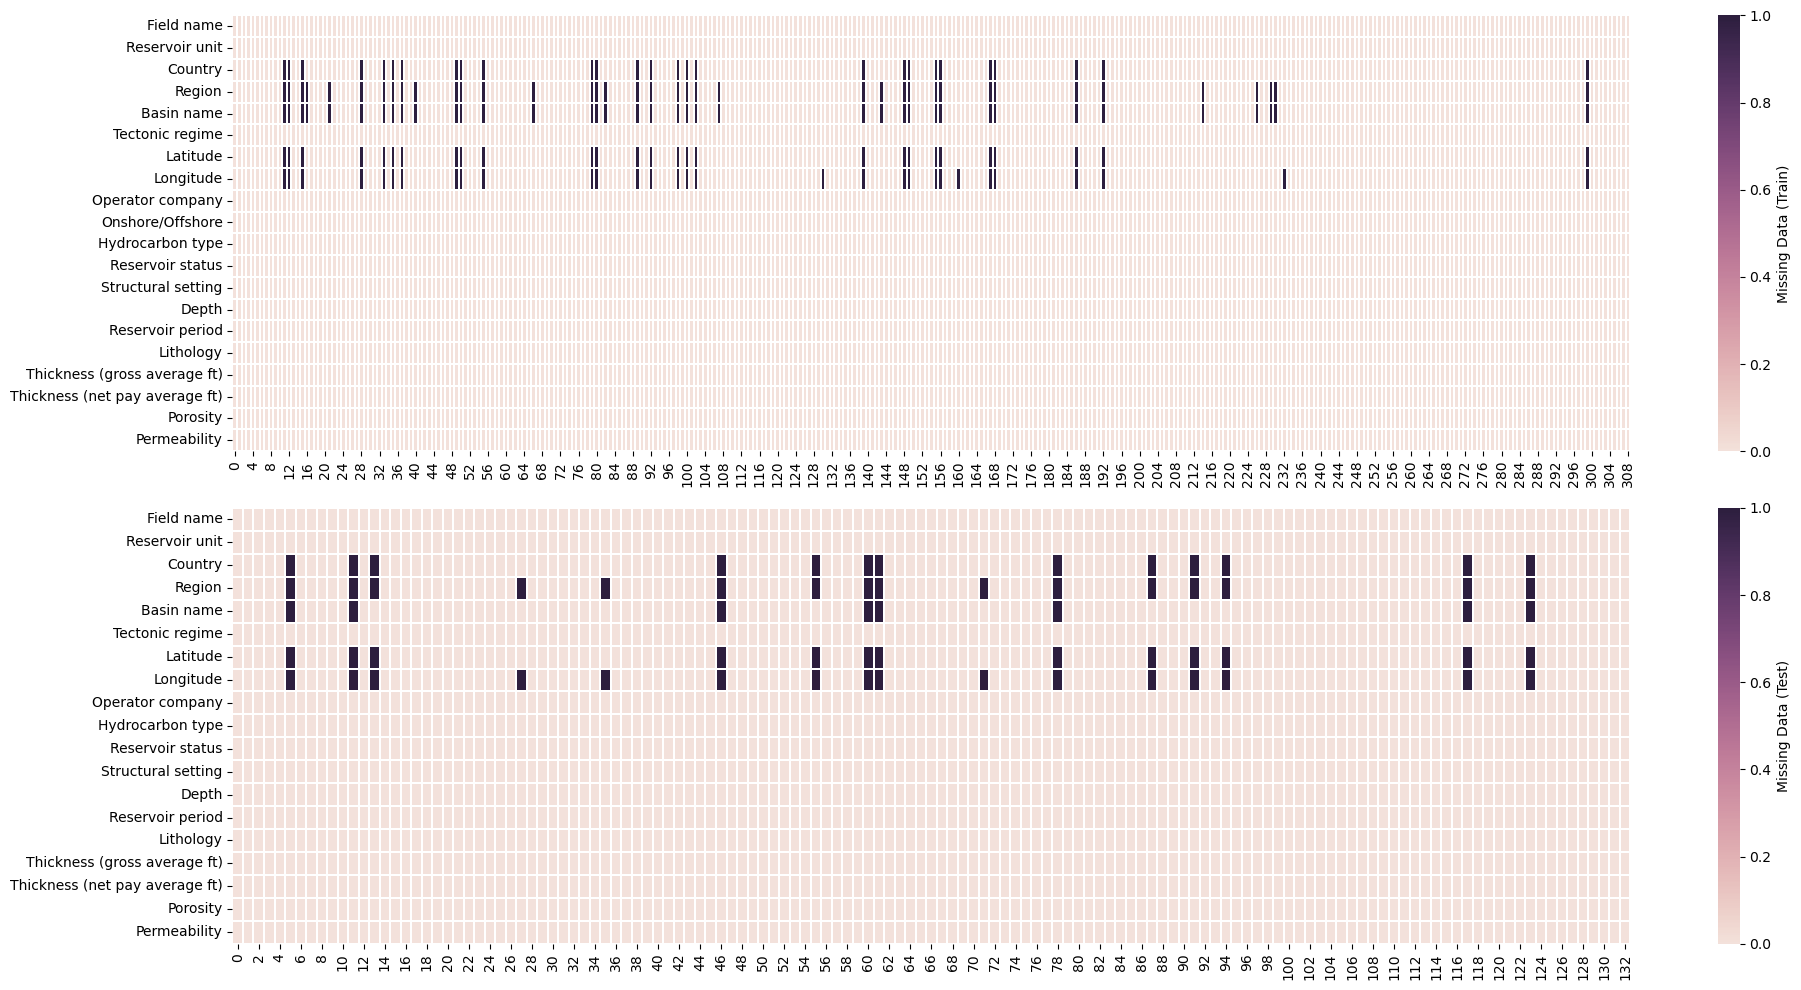

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.03)

sns.heatmap(test.isna().transpose(), cmap=cmap, ax=ax2,
            cbar_kws={'label': 'Missing Data (Test)'}, linewidths=0.03)

plt.tight_layout()
plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=200)
plt.show()
